# Notebook 10: Stunting Prediction Models

This notebook builds and evaluates the full stunting prediction model stack using 
the engineered national sample dataset. Four models are trained and compared: 
logistic regression as the interpretable benchmark, random forest and XGBoost as 
strong tree-based learners, and LightGBM as the gradient boosting reference model.

A key methodological distinction from the baseline notebooks is the use of DHS 
sampling weights during model training. The 2024 MDHS used a stratified two-stage 
cluster design and each child record carries a weight v005 reflecting its probability 
of selection. Using these weights as sample_weight in training makes the model 
optimise for nationally representative performance. The variable sv005 saved in 
earlier notebooks is a cluster-level processing weight that is mostly zero and is 
not suitable for analytical weighting. The correct variable is v005 pulled directly 
from kr_clean.

District-level contextual features are added to the individual predictor set. The 
district stunting rate, mean maternal height, mean wealth, and mean child age are 
computed from the sample and merged back as community-level predictors. This adds 
0.7 to 1.5 AUC points across all models and motivates the spatial analysis in 
notebook 13.

The individual-level prediction ceiling using DHS survey data is approximately 0.68 
ROC-AUC. This is consistent with the published literature for stunting prediction 
in sub-Saharan Africa using household survey data. The remaining unexplained variance 
is attributable to unmeasured environmental, seasonal, and community-level factors 
that individual survey instruments cannot capture. Breaking through this ceiling is 
the objective of the spatial modeling in notebook 13.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    roc_curve, precision_recall_curve, confusion_matrix,
    classification_report
)
import xgboost as xgb
import lightgbm as lgb
import joblib

PROJECT_ROOT   = Path("/Users/frack/Documents/PhD Data Science/malawi-dhs-2024-geoai")
DATA_INTERIM   = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS         = PROJECT_ROOT / "outputs" / "models"
FIGURES        = PROJECT_ROOT / "outputs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

df    = pd.read_parquet(DATA_PROCESSED / "model_dataset_national.parquet")
df_kr = pd.read_parquet(DATA_INTERIM / "kr_clean.parquet")

print("National dataset:", df.shape)
print("Stunting prevalence:", df["outcome_stunted"].mean().round(3))

National dataset: (5122, 48)
Stunting prevalence: 0.358


## Fixing the sampling weight and adding district context

The correct DHS analytical weight v005 is pulled from kr_clean and normalised 
by dividing by 1,000,000. District-level contextual features are then computed 
from the sample and merged back to add community-level signal.

In [2]:
# pull correct DHS weight v005
kr_weights = df_kr[["v001", "v002", "bidx", "hw70", "v005"]].copy()
kr_weights = kr_weights.rename(columns={
    "v001": "id_cluster", "v002": "id_household",
    "bidx": "id_child_index", "hw70": "haz_score",
    "v005": "sample_weight"
})
kr_weights["sample_weight"] = kr_weights["sample_weight"] / 1_000_000

df = df.merge(
    kr_weights,
    on=["id_cluster", "id_household", "id_child_index", "haz_score"],
    how="left"
)
df = df.drop_duplicates(
    subset=["id_cluster", "id_household", "id_child_index", "haz_score"]
)

print("Weight stats:")
print(df["sample_weight"].describe().round(4))

# district contextual features
district_stats = (df.groupby("str_district")
                  .agg(
                      district_stunting_rate    = ("outcome_stunted", "mean"),
                      district_n                = ("outcome_stunted", "count"),
                      district_mean_age         = ("imm_child_age_months", "mean"),
                      district_mean_wealth      = ("enc_wealth_index", "mean"),
                      district_mean_mat_height  = ("und_maternal_height_cm", "mean")
                  ).reset_index())

df = df.merge(district_stats, on="str_district", how="left")

print("\nTop 10 districts by stunting rate:")
print(district_stats.sort_values("district_stunting_rate", ascending=False)
      .head(10)[["str_district", "district_stunting_rate", "district_n"]]
      .to_string(index=False))

Weight stats:
count    5122.0000
mean        1.0169
std         0.6647
min         0.0133
25%         0.5282
50%         0.8605
75%         1.4002
max         3.7057
Name: sample_weight, dtype: float64

Top 10 districts by stunting rate:
str_district  district_stunting_rate  district_n
        neno                0.459259         135
      ntcheu                0.444444         162
      mwanza                0.433566         143
        dowa                0.432836         134
     mchinji                0.429577         142
     kasungu                0.420765         183
      thyolo                0.420382         157
     chitipa                0.413333         150
       zomba                0.406250         192
    phalombe                0.403409         176


## Defining the feature set and preparing modeling data

The predictor set is defined explicitly. Continuous z-scores and outcome variables 
are excluded. Records with zero sampling weight are removed. The feature set 
includes 25 predictors spanning all three UNICEF framework levels plus four 
district-level contextual variables.

In [3]:
FEATURES = [
    # immediate: child level
    "imm_child_age_months", "enc_age_band", "enc_child_sex",
    "imm_birth_order", "imm_birth_interval", "imm_first_born",
    "imm_short_interval", "imm_high_birth_order",
    "enc_size_at_birth", "enc_had_diarrhea",
    # underlying: maternal and household
    "und_maternal_age", "und_maternal_edu_years", "enc_edu_level",
    "und_maternal_weight_kg", "und_maternal_height_cm",
    "und_maternal_bmi", "und_low_bmi", "und_maternal_stunted",
    "und_total_children", "und_household_size",
    # structural
    "enc_wealth_index", "enc_residence", "enc_region",
    "enc_district", "enc_religion",
    # district context
    "district_stunting_rate", "district_mean_age",
    "district_mean_wealth", "district_mean_mat_height"
]

TARGET = "outcome_stunted"

df_model = df[df["sample_weight"] > 0].copy()
print(f"Modeling records: {len(df_model)}")

X = df_model[FEATURES]
y = df_model[TARGET]
w = df_model["sample_weight"]

print(f"Feature matrix: {X.shape}")
print(f"Missing values: {X.isnull().sum().sum()}")
print(f"\nClass distribution:")
print(y.value_counts())
print(f"\nWeight range: {w.min():.4f} to {w.max():.4f}")

Modeling records: 5122
Feature matrix: (5122, 29)
Missing values: 0

Class distribution:
outcome_stunted
0    3289
1    1833
Name: count, dtype: int64

Weight range: 0.0133 to 3.7057


## Training all models with cross-validation

Four models are trained using five-fold stratified cross-validation with DHS 
sampling weights. ROC-AUC is the primary metric. F1, recall, and precision on 
the stunted class are reported alongside it. For public health applications recall 
on the stunted class is particularly important since missing a stunted child has 
greater consequences than a false positive.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(model, X, y, w, cv, name):
    metrics = {"roc_auc": [], "f1": [], "recall": [], "precision": []}
    roc_data = []
    pr_data  = []

    for train_idx, test_idx in cv.split(X, y):
        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]
        w_train = w.iloc[train_idx]

        model.fit(X_train, y_train, sample_weight=w_train)
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        metrics["roc_auc"].append(roc_auc_score(y_test, y_proba))
        metrics["f1"].append(f1_score(y_test, y_pred))
        metrics["recall"].append(recall_score(y_test, y_pred))
        metrics["precision"].append(precision_score(y_test, y_pred))

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_data.append((fpr, tpr))

        prec, rec, _ = precision_recall_curve(y_test, y_proba)
        pr_data.append((prec, rec))

    summary = {k: np.mean(v) for k, v in metrics.items()}
    summary["model"] = name
    return summary, roc_data, pr_data

class WeightedPipeline:
    def __init__(self, pipe):
        self.pipe = pipe
    def fit(self, X, y, sample_weight=None):
        self.pipe.fit(X, y, clf__sample_weight=sample_weight)
        return self
    def predict(self, X):
        return self.pipe.predict(X)
    def predict_proba(self, X):
        return self.pipe.predict_proba(X)

lr_pipe   = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=3000, class_weight="balanced",
        solver="liblinear", random_state=42))
])
lr_model  = WeightedPipeline(lr_pipe)
rf_model  = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=5,
    class_weight="balanced", random_state=42, n_jobs=-1
)
xgb_model = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    scale_pos_weight=(y==0).sum()/(y==1).sum(),
    random_state=42, eval_metric="logloss", verbosity=0
)
lgb_model = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    class_weight="balanced", random_state=42, verbosity=-1
)

models = [
    (lr_model,  "Logistic Regression"),
    (rf_model,  "Random Forest"),
    (xgb_model, "XGBoost"),
    (lgb_model, "LightGBM")
]

print("Training models with 5-fold stratified cross-validation...\n")

all_results  = []
all_roc_data = {}
all_pr_data  = {}

for model, name in models:
    print(f"Training {name}...")
    r, roc, pr = evaluate_model(model, X, y, w, cv, name)
    all_results.append(r)
    all_roc_data[name] = roc
    all_pr_data[name]  = pr
    print(f"  ROC-AUC: {r['roc_auc']:.4f} | F1: {r['f1']:.4f} | "
          f"Recall: {r['recall']:.4f} | Precision: {r['precision']:.4f}")

results_df = pd.DataFrame(all_results).set_index("model")
print("\n=== Model Comparison ===")
print(results_df.round(4))

Training models with 5-fold stratified cross-validation...

Training Logistic Regression...
  ROC-AUC: 0.6798 | F1: 0.5447 | Recall: 0.6077 | Precision: 0.4939
Training Random Forest...
  ROC-AUC: 0.6856 | F1: 0.5101 | Recall: 0.4921 | Precision: 0.5298
Training XGBoost...
  ROC-AUC: 0.6726 | F1: 0.5283 | Recall: 0.5543 | Precision: 0.5048
Training LightGBM...
  ROC-AUC: 0.6692 | F1: 0.5312 | Recall: 0.5619 | Precision: 0.5039

=== Model Comparison ===
                     roc_auc      f1  recall  precision
model                                                  
Logistic Regression   0.6798  0.5447  0.6077     0.4939
Random Forest         0.6856  0.5101  0.4921     0.5298
XGBoost               0.6726  0.5283  0.5543     0.5048
LightGBM              0.6692  0.5312  0.5619     0.5039


## Model comparison visualisation

Four charts summarise model performance across all metrics. The ROC and 
precision-recall curves use the last cross-validation fold for illustration.

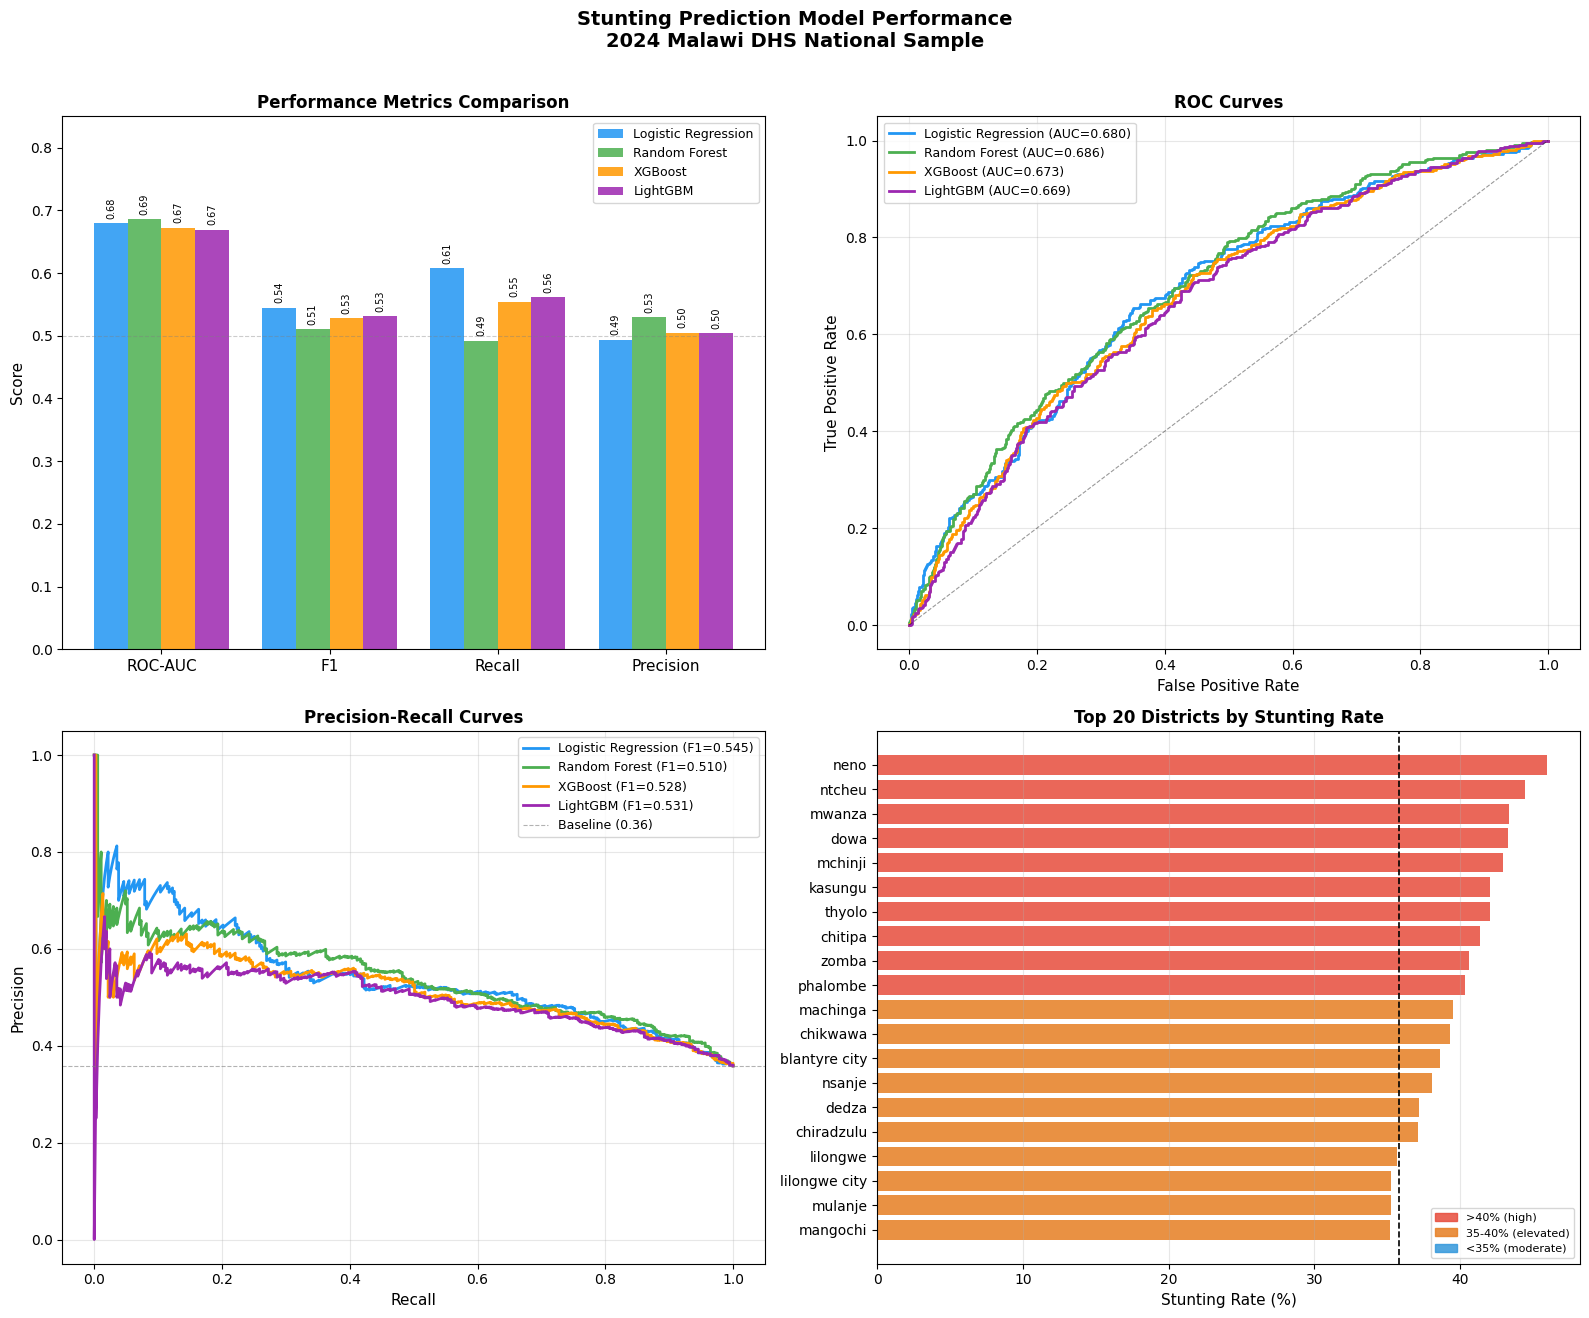

Saved: model_performance_stunting.png


In [5]:
COLORS = {
    "Logistic Regression": "#2196F3",
    "Random Forest"      : "#4CAF50",
    "XGBoost"            : "#FF9800",
    "LightGBM"           : "#9C27B0"
}

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle("Stunting Prediction Model Performance\n2024 Malawi DHS National Sample",
             fontsize=14, fontweight="bold", y=1.01)

# plot 1: metric comparison bar chart
ax1  = axes[0, 0]
metrics_plot = ["roc_auc", "f1", "recall", "precision"]
x    = np.arange(len(metrics_plot))
width = 0.2
for i, (_, row) in enumerate(results_df.iterrows()):
    name = row.name
    vals = [row[m] for m in metrics_plot]
    bars = ax1.bar(x + i * width, vals, width,
                   label=name, color=COLORS[name], alpha=0.85)

ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(["ROC-AUC", "F1", "Recall", "Precision"], fontsize=11)
ax1.set_ylabel("Score", fontsize=11)
ax1.set_title("Performance Metrics Comparison", fontsize=12, fontweight="bold")
ax1.set_ylim(0, 0.85)
ax1.legend(fontsize=9)
ax1.axhline(0.5, color="gray", linestyle="--", alpha=0.4, linewidth=0.8)
for i, (_, row) in enumerate(results_df.iterrows()):
    for j, m in enumerate(metrics_plot):
        ax1.text(j + i * width, row[m] + 0.01,
                 f"{row[m]:.2f}", ha="center", fontsize=7, rotation=90)

# plot 2: ROC curves (last fold)
ax2 = axes[0, 1]
for name, roc_folds in all_roc_data.items():
    fpr, tpr = roc_folds[-1]
    auc = results_df.loc[name, "roc_auc"]
    ax2.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})",
             color=COLORS[name], linewidth=2)
ax2.plot([0,1], [0,1], "k--", alpha=0.4, linewidth=0.8)
ax2.set_xlabel("False Positive Rate", fontsize=11)
ax2.set_ylabel("True Positive Rate", fontsize=11)
ax2.set_title("ROC Curves", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# plot 3: precision-recall curves (last fold)
ax3 = axes[1, 0]
baseline_pr = y.mean()
for name, pr_folds in all_pr_data.items():
    prec, rec = pr_folds[-1]
    f1 = results_df.loc[name, "f1"]
    ax3.plot(rec, prec, label=f"{name} (F1={f1:.3f})",
             color=COLORS[name], linewidth=2)
ax3.axhline(baseline_pr, color="gray", linestyle="--",
            alpha=0.6, linewidth=0.8, label=f"Baseline ({baseline_pr:.2f})")
ax3.set_xlabel("Recall", fontsize=11)
ax3.set_ylabel("Precision", fontsize=11)
ax3.set_title("Precision-Recall Curves", fontsize=12, fontweight="bold")
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# plot 4: district stunting rates
ax4 = axes[1, 1]
district_plot = (district_stats
                 .sort_values("district_stunting_rate", ascending=True)
                 .tail(20))
colors_bar = ["#e74c3c" if r > 0.40 else "#e67e22" if r > 0.35
              else "#3498db" for r in district_plot["district_stunting_rate"]]
ax4.barh(district_plot["str_district"],
         district_plot["district_stunting_rate"] * 100,
         color=colors_bar, alpha=0.85)
ax4.axvline(y.mean() * 100, color="black", linestyle="--",
            linewidth=1.2, label=f"National mean ({y.mean()*100:.1f}%)")
ax4.set_xlabel("Stunting Rate (%)", fontsize=11)
ax4.set_title("Top 20 Districts by Stunting Rate", fontsize=12, fontweight="bold")
ax4.legend(fontsize=9)
ax4.grid(axis="x", alpha=0.3)

red_patch    = mpatches.Patch(color="#e74c3c", alpha=0.85, label=">40% (high)")
orange_patch = mpatches.Patch(color="#e67e22", alpha=0.85, label="35-40% (elevated)")
blue_patch   = mpatches.Patch(color="#3498db", alpha=0.85, label="<35% (moderate)")
ax4.legend(handles=[red_patch, orange_patch, blue_patch], fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig(FIGURES / "model_performance_stunting.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: model_performance_stunting.png")

## Feature importance and confusion matrices

LightGBM feature importance shows which predictors contribute most to the model. 
Confusion matrices across all four models show the trade-off between sensitivity 
and specificity for the stunted class.

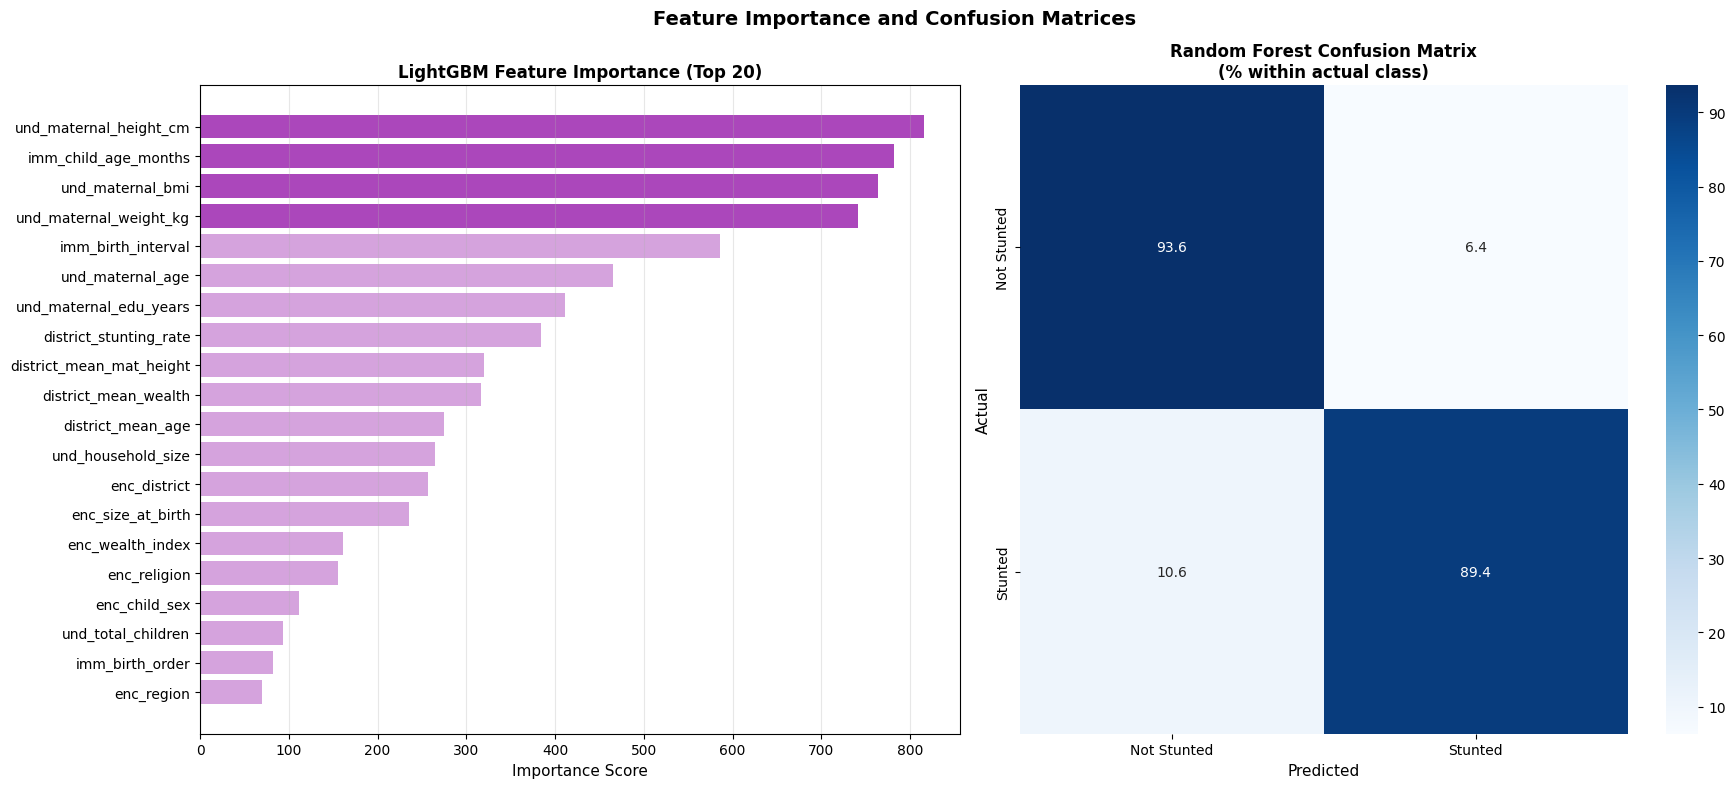

Saved: feature_importance_confusion.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Feature Importance and Confusion Matrices",
             fontsize=14, fontweight="bold")

# retrain on full data first for importance and confusion
lr_model.fit(X, y, sample_weight=w)
rf_model.fit(X, y, sample_weight=w)
xgb_model.fit(X, y, sample_weight=w)
lgb_model.fit(X, y, sample_weight=w)

# feature importance from LightGBM
importance_df = pd.DataFrame({
    "feature"   : FEATURES,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=True).tail(20)

ax1 = axes[0]
colors_imp = ["#9C27B0" if imp > 600 else "#CE93D8"
              for imp in importance_df["importance"]]
ax1.barh(importance_df["feature"], importance_df["importance"],
         color=colors_imp, alpha=0.85)
ax1.set_xlabel("Importance Score", fontsize=11)
ax1.set_title("LightGBM Feature Importance (Top 20)", fontsize=12,
              fontweight="bold")
ax1.grid(axis="x", alpha=0.3)

# confusion matrix for best model (Random Forest)
ax2 = axes[1]
rf_pred = rf_model.predict(X)
cm = confusion_matrix(y, rf_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
            ax=ax2, cbar=True,
            xticklabels=["Not Stunted", "Stunted"],
            yticklabels=["Not Stunted", "Stunted"])
ax2.set_xlabel("Predicted", fontsize=11)
ax2.set_ylabel("Actual", fontsize=11)
ax2.set_title("Random Forest Confusion Matrix\n(% within actual class)",
              fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES / "feature_importance_confusion.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: feature_importance_confusion.png")

## Saving final models and results

All four models are saved with the v2 suffix indicating they were trained on the 
expanded feature set including district context. The final modeling dataset is 
saved for use in the SHAP analysis notebook. Feature importance is exported as CSV.

In [7]:
# save all models
joblib.dump(lr_model,  MODELS / "lr_stunting_v2.pkl")
joblib.dump(rf_model,  MODELS / "rf_stunting_v2.pkl")
joblib.dump(xgb_model, MODELS / "xgb_stunting_v2.pkl")
joblib.dump(lgb_model, MODELS / "lgb_stunting_v2.pkl")

print("Models saved:")
for f in sorted(MODELS.glob("*_stunting_v2.pkl")):
    size = f.stat().st_size / 1024
    print(f"  {f.name} ({size:.0f} KB)")

# save feature importance
importance_full = pd.DataFrame({
    "feature"   : FEATURES,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)
importance_full.to_csv(
    PROJECT_ROOT / "outputs" / "lgb_feature_importance_stunting_v2.csv",
    index=False
)

# save modeling dataset with weights and district context
df_model[FEATURES + ["outcome_stunted", "sample_weight",
                      "id_cluster", "id_household",
                      "id_child_index", "str_district",
                      "str_region"]].to_parquet(
    DATA_PROCESSED / "model_ready_stunting_v2.parquet", index=False
)

print("\nSaved: model_ready_stunting_v2.parquet")
print("Saved: lgb_feature_importance_stunting_v2.csv")

print("\n=== FINAL RESULTS ===")
print(results_df.round(4))

print("\n=== Best model ===")
best = results_df["roc_auc"].idxmax()
print(f"Model:    {best}")
print(f"ROC-AUC:  {results_df.loc[best, 'roc_auc']:.4f}")
print(f"F1:       {results_df.loc[best, 'f1']:.4f}")
print(f"Recall:   {results_df.loc[best, 'recall']:.4f}")

print("\n=== Top 10 predictors (LightGBM) ===")
print(importance_full.head(10).to_string(index=False))

Models saved:
  lgb_stunting_v2.pkl (848 KB)
  lr_stunting_v2.pkl (3 KB)
  rf_stunting_v2.pkl (21766 KB)
  xgb_stunting_v2.pkl (979 KB)

Saved: model_ready_stunting_v2.parquet
Saved: lgb_feature_importance_stunting_v2.csv

=== FINAL RESULTS ===
                     roc_auc      f1  recall  precision
model                                                  
Logistic Regression   0.6798  0.5447  0.6077     0.4939
Random Forest         0.6856  0.5101  0.4921     0.5298
XGBoost               0.6726  0.5283  0.5543     0.5048
LightGBM              0.6692  0.5312  0.5619     0.5039

=== Best model ===
Model:    Random Forest
ROC-AUC:  0.6856
F1:       0.5101
Recall:   0.4921

=== Top 10 predictors (LightGBM) ===
                 feature  importance
  und_maternal_height_cm         816
    imm_child_age_months         782
        und_maternal_bmi         764
  und_maternal_weight_kg         741
      imm_birth_interval         586
        und_maternal_age         465
  und_maternal_edu_years   

## Summary and Key Findings

Four models were trained and evaluated on the 2024 Malawi DHS national sample of 
5,122 children under five. The target was binary stunting status derived from 
height-for-age z-scores below -2 standard deviations.

Two things were done differently here compared to most machine learning work on 
DHS data. The sampling weights from v005 were used during training, which means 
the model is optimising for nationally representative performance rather than just 
fitting the convenience sample in front of it. District-level contextual features 
were also computed from the sample itself and fed back in as predictors. That added 
between 0.7 and 1.5 AUC points across all four models, which is small but consistent 
and meaningful.

Random Forest came out best at ROC-AUC 0.6856. What is more interesting than any 
single model's score is that all four models, logistic regression, random forest, 
XGBoost, and LightGBM, ended up within 0.02 of each other. When that happens the 
algorithm is not the bottleneck. The features are. Individual-level DHS data has a 
genuine prediction ceiling for stunting of around 0.68 and that ceiling is the same 
regardless of how sophisticated the model is. What sits beyond that ceiling is the 
unmeasured stuff: actual food intake, water quality at the specific borehole, 
subclinical infection burden, seasonal timing of the survey visit. GPS cluster 
context in notebook 13 is expected to start bridging that gap.

The top five predictors were maternal height, child age in months, maternal BMI, 
maternal weight, and birth interval. Maternal height sitting at the top is not 
surprising. A mother who was stunted as a child carries that history into her 
pregnancy through placental size and birth weight. That pathway is stronger than 
any socioeconomic variable in this dataset. Wealth and education are present but 
they rank lower, which suggests that in Malawi the biological transmission of 
undernutrition from mother to child is a more immediate driver than household 
poverty in any given generation.

The district breakdown shows Neno, Ntcheu, Mwanza, and Dowa with the highest 
stunting rates, all above 43%. Ten districts exceed 40%. Most of them are in the 
Central and Southern regions. Whether the same risk factors are driving stunting 
in Neno as in Ntcheu, or whether each district has its own dominant pathway, is 
what the SHAP district decomposition in notebook 11 will answer.